## Dự báo giá bất động sản dựa trên các đặc trưng địa lý và tiện ích


## Dữ liệu
Dữ liệu sử dụng trong bài toán là bộ dữ liệu **Real Estate Valuation** (định giá bất động sản).

Dữ liệu được lưu dưới dạng file Excel (`raw-data.xlsx`) và được đọc vào bằng thư viện `pandas`.

Bộ dữ liệu gồm các thuộc tính liên quan đến vị trí và tiện ích xung quanh của bất động sản, từ đó dự đoán giá nhà trên mỗi đơn vị diện tích.


## Mục tiêu
Xây dựng mô hình hồi quy để dự đoán:

> **Giá nhà trên mỗi đơn vị diện tích**

dựa trên các yếu tố:
- Khoảng cách giao thông
- Tiện ích xung quanh
- Vị trí địa lý

## Hướng giải quyết

Giả sử rằng giá nhà trên mỗi đơn vị diện tích (ký hiệu: `y`) là đại lượng phụ thuộc tuyến tính vào các yếu tố như khoảng cách đến MRT, số lượng cửa hàng tiện lợi và vị trí địa lý (ký hiệu: `x1, x2, ... x_n`).

Cụ thể trong bài toán này:

- `x1`: Khoảng cách đến trạm MRT gần nhất (X3)
- `x2`: Số lượng cửa hàng tiện lợi (X4)
- `x3`: Vĩ độ (X5)
- `x4`: Kinh độ (X6)

Mối quan hệ được giả định như sau:

`y = w0 + w1*x1 + w2*x2 + w3*x3 + w4*x4`

Trong đó:
- `y`: Giá nhà trên mỗi đơn vị diện tích
- `w0`: hệ số bias (intercept)
- `w1, w2, w3, w4`: trọng số của các đặc trưng


### Mục tiêu

Tìm được bộ trọng số:

`[w0, w1, w2, w3, w4]`

sao cho mô hình dự đoán giá nhà gần nhất với giá trị thực tế.


### Phương pháp

Sử dụng các mô hình hồi quy tuyến tính:

- **Linear Regression**: mô hình cơ bản
- **Ridge Regression**: cải tiến với regularization để giảm overfitting

Mô hình sẽ được huấn luyện trên tập dữ liệu training và đánh giá trên tập test thông qua các chỉ số như:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)


### Ý nghĩa

Mô hình học được mối quan hệ giữa:
- Vị trí địa lý
- Tiện ích xung quanh
- Hạ tầng giao thông

và giá trị bất động sản, từ đó có thể dự đoán giá nhà cho các dữ liệu mới.

## Các bước thực hiện

### 1. Import thư viện

- matplotlib, seaborn: phục vụ trực quan hóa dữ liệu
- numpy: tính toán các phép biến đổi trên ma trận / vector
- math: thực hiện một số hàm tính toán
- pandas: phục vụ chuyển đổi trên dữ liệu dạng bảng
- scikit-learn: (sklearn) thư viện hỗ trợ xây dựng các mô hình học máy, các hàm training và testing.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn import datasets, linear_model
from sklearn.linear_model import ridge_regression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 2. Đọc dữ liệu

Dữ liệu về giá nhà bất động sản được đọc thông qua file có tên là `raw_data.xlsx` được nằm trong folder `data/raw`
Dữ liệu được đọc vào bằng thư viện `pandas` thông qua hàm `read_excel()`.

Dữ liệu nhận về ở dạng **DataFrame** với các thành phần:

- Data: bảng dữ liệu gồm các thuộc tính của bất động sản.
- Target: cột giá nhà trên mỗi đơn vị diện tích.


### Thông tin dữ liệu

- Số chiều dữ liệu:
- Kiểu dữ liệu: pandas DataFrame
- Các thuộc tính:
  - X3: khoảng cách đến MRT
  - X4: số cửa hàng tiện lợi
  - X5: vĩ độ
  - X6: kinh độ
  - Y: giá nhà


In [37]:
# đọc dữ liệu từ file Excel
read_data = pd.read_excel("../data/raw/raw-data.xlsx")
# Thông tin tổng quan
print("Số chiều dữ liệu: ", read_data.shape)
print("Kiểu dữ liệu: ", type(read_data))

# Thông tin chi tiết
print("Thông tin chi tiết: ", read_data.info())

# Mô tả
print("Mô tả: ", read_data.describe())

# In 5 dữ liệu đầu tiên
print("5 mẫu dữ liệu đầu tiên: ", read_data.head())

Số chiều dữ liệu:  (414, 8)
Kiểu dữ liệu:  <class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
Thông tin chi tiết:  None
Mô tả:                 No  X1 transaction date  X2 house age  \
count 

### 3. Chia dữ liệu làm 2 phần training 335 mẫu và testing 80 mẫu



In [38]:
X =read_data[[
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude"
]]

Y = read_data["Y house price of unit area"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

### 4. Chuẩn hóa dữ liệu
Trong tập dữ liệu này, các đặc trưng có đơn vị và khoảng giá trị rất khác nhau:
- X3: Có giá trị lên đến hàng nghìn mét.
- X4: Chỉ dao động từ 0 đến 10.
Nếu không chuẩn hóa, các thuật toán như Ridge sẽ bị đánh lừa bởi các con số lớn, dẫn đến việc phạt sai các trọng số. Chúng ta sử dụng **(StandardScaler)** để đưa tất cả về cùng một phân phối chuẩn:
$$z = \frac{x - \mu}{\sigma}$$
Trong đó:
- $\mu$: Giá trị trung bình
- $\sigma$: Độ lệch chuẩn

## Khởi tạo Scalar


In [39]:
scalar = StandardScaler()

## Chuẩn hóa tập luyện và kiểm thử


In [40]:
X_train_scaler = scalar.fit_transform(X_train)
X_test_scaler = scalar.transform(X_test)


### 5. Xây dựng mô hình hồi quy sử dụng thư viện Sklearn
Trong bài toán này, sử dụng mô hình **(Linear Regression / Ridge Regression)** để dự đoán giá nhà trên mỗi đơn vị diện tích.

Mô hình giả định rằng giá nhà (`y`) có mối quan hệ tuyến tính với các đặc trưng đầu vào (`X3, X4, X5, X6`).
- **Linear Regression**: `linear_model.LinearRegression()`
- **Ridge Regression**: `linear_model.Ridge()`

Mô hình sẽ học được các tham số:
- `coef_`: hệ số trọng số của từng đặc trưng
- `intercept_`: hệ số bias

In [32]:
regr = linear_model.LinearRegression()
ridge = linear_model.Ridge(alpha=0.1)

### 6. Training mô hình

Sử dụng tập dữ liệu training (`X_train`, `Y_train`) đã được chia ở bước trước để huấn luyện 2 mô hình

Quá trình training giúp mô hình học được mối quan hệ giữa các đặc trưng đầu vào và giá nhà.

###  Mục tiêu

Tìm được bộ trọng số:

`[w0, w1, w2, w3, w4]`

sao cho mô hình dự đoán giá nhà gần với giá trị thực tế nhất.


In [41]:
regr = linear_model.LinearRegression()
regr.fit(X_train_scaler, Y_train)
print("[w1,.., w_n] =", regr.coef_)
print("[w0 = ]", regr.intercept_)

[w1,.., w_n] = [-5.72634398  2.97191908  2.76273461 -0.13220604]
[w0 = ] 38.39154078549813


In [42]:
ridge = linear_model.Ridge(alpha=0.1)
ridge.fit(X_train_scaler, Y_train)
print("[w1,.., w_n] =", ridge.coef_)
print("[w0 = ]", ridge.intercept_)

[w1,.., w_n] = [-5.72096166  2.97235914  2.76324852 -0.12830099]
[w0 = ] 38.39154078549813


### Nhận xét khi sử dụng Linear Regression và Ridge Regression

Sau khi huấn luyện hai mô hình, ta thu được các hệ số:

- **Linear Regression**:
  - Hệ số có giá trị ~ 2,76
  - Intercept khá ổn ~ 38,39

- **Ridge Regression**:
  - Các hệ số tương đồng với linear



### 7. Dự đoán các mẫu dữ liệu trong tập test

Sau khi huấn luyện mô hình, sử dụng mô hình để dự đoán giá nhà trên tập dữ liệu test (`X_test`) bằng cả hai mô hình.


So sánh giữa:
- Giá trị thực tế (`Y_test`)
- Giá trị dự đoán từ linear (`Y_pred_linear`)
- Giá trị dự đoán từ Ridge (`Y_pred_ridge`)
- Sai lệch giữa hai giá trị

để đánh giá sơ bộ độ chính xác của mô hình.

In [51]:
Y_pred_linear = regr.predict(X_test_scaler)
Y_pred_ridge = ridge.predict(X_test_scaler)
log_data = pd.DataFrame({
    "Thực tế": Y_test.values,
    "Linear": Y_pred_linear,
    "Ridge": Y_pred_ridge,
    "Lệch Linear": abs(Y_test.values - Y_pred_linear),
    "Lệch Ridge": abs(Y_test.values - Y_pred_ridge)
})
print(log_data)

### Nhận xét sau khi sử dụng 2 mô hình để test

- Cả hai mô hình đều đưa ra giá trị dự đoán gần với giá trị thực tế.
- Tuy nhiên:
- Sai lệch giữa hai mô hình không quá lớn → dữ liệu không bị quá khớp nghiêm trọng


### 7. Đánh giá

Để đánh giá độ chính xác của mô hình, sử dụng hai độ đo phổ biến:

Sử dụng độ đo MSE, RMSE:
> $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$

> $\text{RMSE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2}.$

###  Kết quả đánh giá

| Mô hình | MSE       | RMSE     |
|--------|-----------|----------|
| Linear Regression | **63.90** | **7.99** |
| Ridge Regression  | **63.90** | **7.99** |


- Cả hai mô hình đều có thông số khá sát
- Sai số trung bình của mô hình vào khoảng **±8 đơn vị giá**
→ Đây là mức sai số **chấp nhận được** so với dữ liệu thực tế

Điều này có nghĩa là:
- Trung bình sai số dự đoán của mô hình vào khoảng **±8 đơn vị giá**
- So với khoảng giá trị thực tế của dataset, sai số này ở mức chấp nhận được
- Linear: fit tốt hơn, phù hợp dữ liệu không quá nhiễu
- Ridge: có chính quy hóa giúp mô hình ổn định, tránh overfitting trong các bài phức tạp



In [52]:
mse_linear_model = mean_squared_error(Y_test, Y_pred_linear)
print("Giá trị MSE của mô hình Linear: ", mse_linear_model)
rmse_linear_model = math.sqrt(mean_squared_error(Y_test, Y_pred_linear))
print("Giá trị RMSE của mô hình Linear: ", rmse_linear_model)

Giá trị MSE của mô hình Linear:  63.90493104708975
Giá trị RMSE của mô hình Linear:  7.994055982233909


In [53]:
mse_ridge_model = mean_squared_error(Y_test, Y_pred_ridge)
print("Giá trị MSE của mô hình Ridge: ", mse_ridge_model)
rmse_ridge_model = math.sqrt(mean_squared_error(Y_test, Y_pred_ridge))
print("Giá trị RMSE của mô hình Ridge: ", rmse_ridge_model)

Giá trị MSE của mô hình Ridge:  63.900682765886025
Giá trị RMSE của mô hình Ridge:  7.993790262815633


### 8. Trực quan hóa dữ liệu

### Vẽ biểu đồ phân phối cho chỉ số thực tế
Sử dụng các biểu đồ để quan sát:
- Phân phối giá trị thực tế
- Phân phối giá trị dự đoán
- So sánh trực tiếp giữa hai giá trị

Qua đó đánh giá trực quan độ chính xác của mô hình.

,values real life
count,83.000000
mean,36.339759
std,13.030948
min,11.200000
25%,26.500000
50%,36.800000
75%,46.650000
max,63.300000


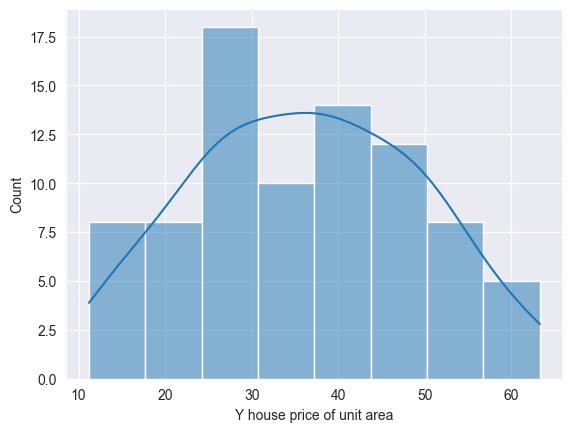

In [54]:
sns.histplot(Y_test, kde=True)
pd.DataFrame(data=Y_test.values, columns=["values real life"]).describe()

### Vẽ biểu đồ phân phối cho chỉ số dự đoán của hai mô hình

,values of linear
count,83.000000
mean,37.253811
std,10.646096
min,4.909549
25%,31.661048
50%,40.966809
75%,44.954050
max,51.849748


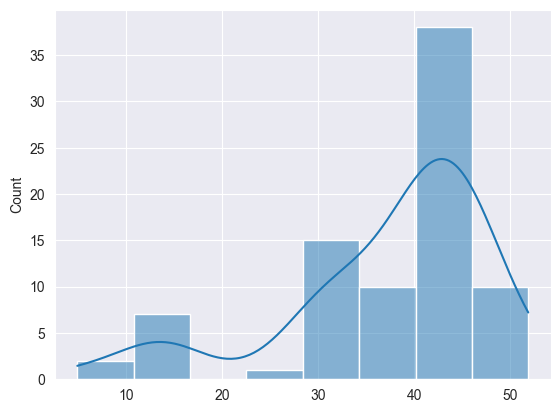

In [55]:
sns.histplot(Y_pred_linear, kde=True)
pd.DataFrame(data=Y_pred_linear, columns=["values of linear"]).describe()

,values of ridge
count,83.000000
mean,37.253811
std,10.646096
min,4.909549
25%,31.661048
50%,40.966809
75%,44.954050
max,51.849748


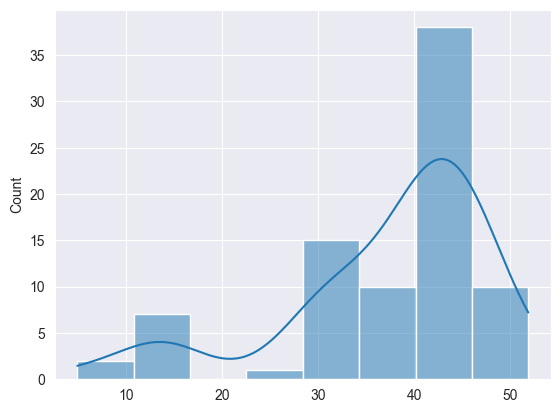

In [56]:
sns.histplot(Y_pred_ridge, kde=True)
pd.DataFrame(data=Y_pred_linear, columns=["values of ridge"]).describe()

### So sánh trực tiếp cả 3 đường

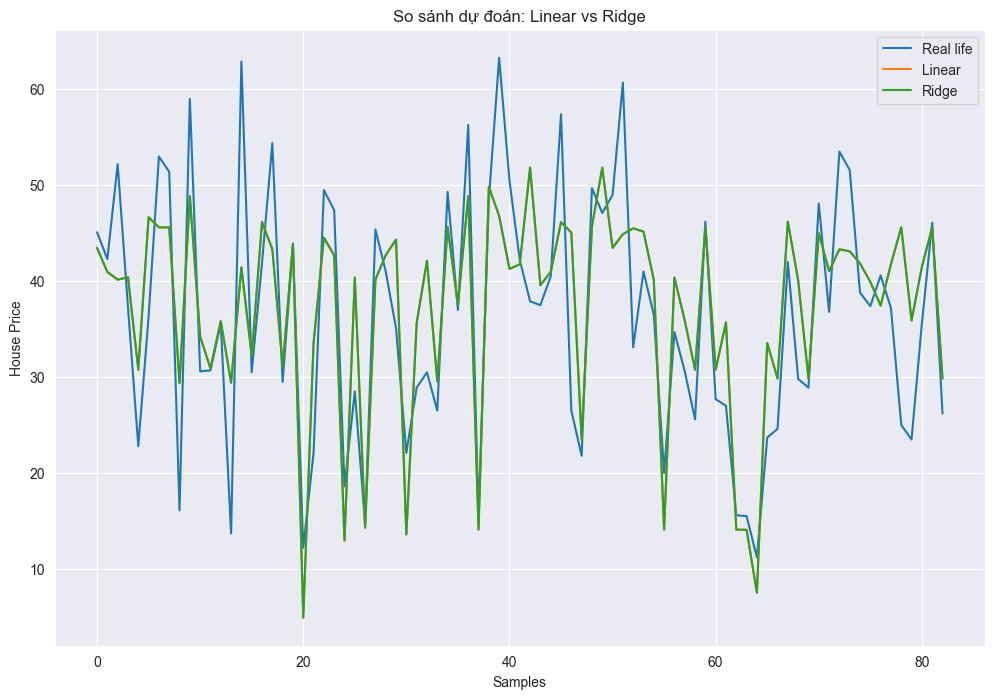

In [57]:
plt.figure(figsize=(12,8))
plt.plot(Y_test.values, label="Real life")
plt.plot(Y_pred_linear, label="Linear")
plt.plot(Y_pred_ridge, label="Ridge")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.title("So sánh dự đoán: Linear vs Ridge")
plt.legend()
plt.show()

### Vẽ biểu đồ so sánh kết quả dự đoán và thực tế


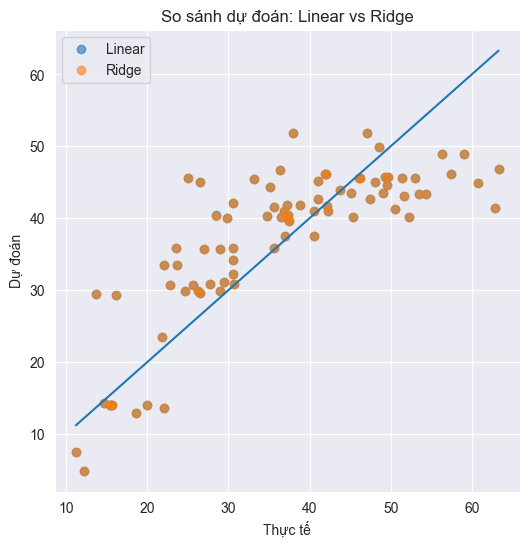

In [63]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, Y_pred_linear, label="Linear", alpha=0.6)
plt.scatter(Y_test, Y_pred_ridge, label="Ridge", alpha=0.6)
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()]
)
plt.xlabel("Thực tế")
plt.ylabel("Dự đoán")
plt.title("So sánh dự đoán: Linear vs Ridge")
plt.legend()
plt.show()

###  Nhận xét

- Biểu đồ phân phối cho thấy giá trị dự đoán có xu hướng gần với phân phối của giá trị thực tế.
- Tuy nhiên, phân phối của dự đoán thường "mượt" hơn và ít biến động hơn so với thực tế.

- Trong biểu đồ so sánh:
  - Đường dự đoán có xu hướng bám theo đường thực tế
  - Tuy nhiên vẫn tồn tại sai lệch ở một số điểm → thể hiện sai số của mô hình



### 9. Kết luận

Trong bài toán dự đoán giá bất động sản, mô hình **Linear Regression** đã cho thấy khả năng nắm bắt được mối quan hệ tuyến tính giữa các đặc trưng (khoảng cách MRT, số cửa hàng tiện lợi, vị trí địa lý) và giá nhà.

Kết quả thực nghiệm cho thấy:
- Độ chính xác của mô hình (R2 Score) đạt khoảng 61.91%, cho thấy bộ dữ liệu giải thích tốt sự biến động của giá nhà.
- Mô hình Linear và Ridge đạt sai số trung bình khoảng ±7.99 đơn vị giá, đây là mức sai số thấp và chấp nhận được trên tập dữ liệu này.


- Dữ liệu có mối quan hệ tương đối tuyến tính → Linear Regression hoạt động hiệu quả
- Tuy nhiên:
  - Mô hình vẫn gặp sai số tại các giá trị ngoại lệ
  - Các yếu tố ảnh hưởng đến giá nhà trong thực tế có thể phức tạp hơn

  - Linear: Phù hợp khi ưu tiên độ chính xác trên tập dữ liệu hiện tại

  - Ridge:  Phù hợp khi cần mô hình ổn định hơn, giảm rủi ro overfitting


